# Pipeline 3 — CatBoost downside risk with broader information

## TL;DR

This notebook tests whether nonlinear risk forecasts improve the already established regime-and-quality allocation. It evaluates prediction quality, actual portfolio outcomes, feature ablations and implementation costs separately.

**Executed test result (2021-01-04–2026-02-20):** CAGR 8.04%; annual volatility 13.08%; daily CVaR95 1.83%; maximum drawdown 17.78%; annual two-sided turnover 3.18. Interpret these together with the incremental comparisons and uncertainty below.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/portfolio-mpl")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The supplied 50 stocks were selected using full-history coverage and alphabetical tie-breaking. Historical delistings and index membership are missing. **Survivorship and universe-selection bias remain.** The data represent a narrow US equity sample, not an emerging market.
6. The original baseline notebook already exposed test results. This test is held out for the **new** hyperparameter choices; it is not a pristine preregistered replication. Previously reported numbers are superseded by the common corrected engine.

## The CatBoost layer

CatBoost is a **risk forecaster feeding a constrained optimizer**, not an unconstrained generator of portfolio weights. The target at formation `t` is

`log( next_21_session_downside_semivariance / trailing_63_session_downside_semivariance )`,

where downside semivariance is `mean(min(simple_return, 0)^2)`. A small fixed `1e-10` floor stabilizes the logarithm. Predicting a change relative to recent downside risk gives a meaningful historical-risk comparator. The predicted log ratio is clipped to `[-3, 3]`, exponentiated, and multiplied by trailing downside risk. This predicts a conditional log-risk score; exponentiation is not claimed to be an unbiased conditional-mean variance forecast.

Pipeline 3 solves

`min_w w.T @ [Sigma_regime + quality_penalty + eta * diag(predicted_downside_variance)] @ w`

under the same portfolio constraints. At `eta = 0`, it exactly recovers Pipeline 2. CVaR remains an evaluation metric.

### Information layers

| Layer | Examples | Availability |
|---|---|---|
| Price and risk | Momentum, reversal, volatility, downside risk, drawdown, beta, residual risk | Prior trading sessions |
| Regimes | HMM stress probability, regime/global asset variance, market correlation | Prior-only monthly HMM |
| Fundamentals | Nine quality ratios, revenue growth, assets, coverage, quality score | SEC as-filed snapshots |
| Trading activity | Dollar volume, relative volume, Amihud illiquidity proxy, intraday range | Original cached OHLCV dataset, reconciled exactly to split prices |
| Reporting process | Filing age/lag, annual-report age, amendment frequency, observed filing count, missingness | Already available SEC filings |
| Calendar and identity | Month seasonality and the supplied stock identifier | Known at formation |

The dataset is broadened beyond prices and financial ratios with **trading activity and reporting-process metadata**. It does not contain point-in-time news, sentiment, macroeconomic vintages or analyst revisions; these are future extensions, not fabricated inputs. Dollar volume is a feature, not a claim that a portfolio capacity limit has been enforced.

### Time-series learning protocol

The model uses expanding annual refits. For every refit, `label_end < fit_date` is required for every training row. Thus an observation whose 21-session target extends into the prediction year is purged. Training includes 2010–2016 monthly snapshots initially, then only matured later history. There is no random train/test split, global feature normalization, shuffled future labels or early stopping on test.

The validation search considers depths 4 and 6, 300 trees, learning rate 0.04, L2 regularization 10 and a compact penalty grid. The no-ML control is counted once. A fixed seed and `has_time=True` preserve chronological handling of the ticker category. CatBoost handles numeric missingness directly. Annual updates during test are part of the locked algorithm, not test-based model selection.

## Data

### Build the dated learning panel and reconcile OHLCV

In [2]:
c = prepare_features(prepare_fundamentals(prepare_context()))
display(c["summary"])
print("Learning panel:", c["panel"].shape)
print("Feature counts:", {name: len(cols)+1 for name, cols in FEATURE_SETS.items()})
display(pd.DataFrame([c["ohlcv_source"]]))
display(c["panel"][["date", "ticker", "price_information_end", "latest_used_available", "label_end", "target_log_risk_ratio"]].head(10))

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,50,213850
validation,2017-01-03,2020-12-31,1007,50,50350
test,2021-01-04,2026-02-20,1289,50,64450


,file_name,sha256,matching_price_cells,source,data_version
0,SP500_Historical_Data.csv,82f3ab3ab6821c54b67a555c1f52c60dc4c162923499f2...,328650,https://www.kaggle.com/datasets/jacksaleeby/s-...,1


,date,ticker,price_information_end,latest_used_available,label_end,target_log_risk_ratio
0,2010-01-04,A,2009-12-31,2009-12-22,2010-02-02,0.705945
1,2010-01-04,AAPL,2009-12-31,2009-10-28,2010-02-02,1.202029
2,2010-01-04,ABT,2009-12-31,2009-11-09,2010-02-02,0.793689
3,2010-01-04,ACGL,2009-12-31,NaT,2010-02-02,-0.218072
4,2010-01-04,ADBE,2009-12-31,2009-10-02,2010-02-02,0.898137
5,2010-01-04,ADI,2009-12-31,2009-11-25,2010-02-02,1.320540
6,2010-01-04,ADP,2009-12-31,2009-11-09,2010-02-02,0.398724
7,2010-01-04,AEE,2009-12-31,2009-11-10,2010-02-02,0.592643
8,2010-01-04,AEP,2009-12-31,2009-11-02,2010-02-02,-0.075432
9,2010-01-04,AES,2009-12-31,2009-11-09,2010-02-02,-0.467273


### Feature coverage and temporal support

In [3]:
coverage = c["panel"][FEATURE_SETS["full"]].notna().mean().rename("nonmissing_fraction").sort_values()
display(coverage.head(18).to_frame().style.format("{:.1%}"))
training_summary = c["panel"].groupby(c["panel"].date.dt.year).agg(rows=("ticker", "size"), companies=("ticker", "nunique"), matured_labels=("label_end", "count"))
display(training_summary)
assert (c["panel"].price_information_end < c["panel"].date).all()

,nonmissing_fraction
fcf_to_assets,59.4%
operating_margin,60.0%
liabilities_to_assets,60.2%
current_ratio,72.6%
accruals_to_assets,82.6%
cfo_to_assets,84.3%
cash_to_assets,86.0%
revenue_growth,88.1%
roa,94.1%
annual_age_days,96.3%


,rows,companies,matured_labels
date,,,
2010,600,50,600
2011,600,50,600
2012,600,50,600
2013,600,50,600
2014,600,50,600
2015,600,50,600
2016,600,50,600
2017,600,50,600
2018,600,50,600


## Results

### Select on validation; keep the zero-strength control

In [4]:
spec = json.loads((ROOT / "artifacts/frozen_spec.json").read_text())
quality_strength = spec["quality_strength"]
ml_spec, validation_grid, validation_runs, validation_forecasts = select_ml(c, quality_strength)
display(styled(validation_grid[["depth", "ml_strength", "risk_score"] + METRIC_COLUMNS]))
assert ml_spec == spec["ml"], "Selection changed: repeat the full validation/freeze protocol before test."
print("Frozen ML specification:", ml_spec)

,depth,ml_strength,risk_score,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
candidate,,,,,,,,,,,,
depth=4;eta=0,4.000,0.000,2.950,15.94%,18.27%,0.901,1.250,32.90%,2.84%,5.69%,3.365,17.478
depth=4;eta=0.25,4.000,0.250,2.850,15.94%,18.27%,0.901,1.249,32.96%,2.84%,5.69%,3.315,17.950
depth=4;eta=0.5,4.000,0.500,4.000,15.95%,18.28%,0.902,1.250,33.03%,2.85%,5.70%,3.276,18.389
depth=4;eta=1,4.000,1.000,5.050,15.91%,18.29%,0.899,1.246,33.16%,2.85%,5.70%,3.208,19.203
depth=6;eta=0.25,6.000,0.250,2.900,15.94%,18.27%,0.902,1.250,32.97%,2.84%,5.69%,3.314,17.937
depth=6;eta=0.5,6.000,0.500,4.300,15.97%,18.28%,0.903,1.251,33.04%,2.85%,5.70%,3.276,18.365
depth=6;eta=1,6.000,1.000,5.950,15.93%,18.29%,0.900,1.248,33.18%,2.85%,5.71%,3.217,19.161


### Audit purging and assess validation predictions

Forecast quality is evaluated against trailing downside risk. Cross-sectional rank correlation is calculated separately each month, then averaged; all 50 assets on a date share the same forecasting cutoff.

,year,fit_date,training_rows,training_dates,last_training_formation,last_training_label_end,prediction_dates,depth,iterations,feature_set,features
0,2017,2017-01-03,4200,84,2016-12-01,2016-12-30,12,4,300,full,47
1,2018,2018-01-02,4750,95,2017-11-01,2017-11-30,12,4,300,full,47
2,2019,2019-01-02,5350,107,2018-11-01,2018-11-30,12,4,300,full,47
3,2020,2020-01-02,6000,120,2019-12-02,2019-12-31,12,4,300,full,47


,rows,months,log_risk_RMSE,mean_monthly_rank_IC,median_monthly_rank_IC
model,,,,,
Historical downside,2400,48,1.236766,0.497413,0.515582
CatBoost,2400,48,1.211635,0.539078,0.559040


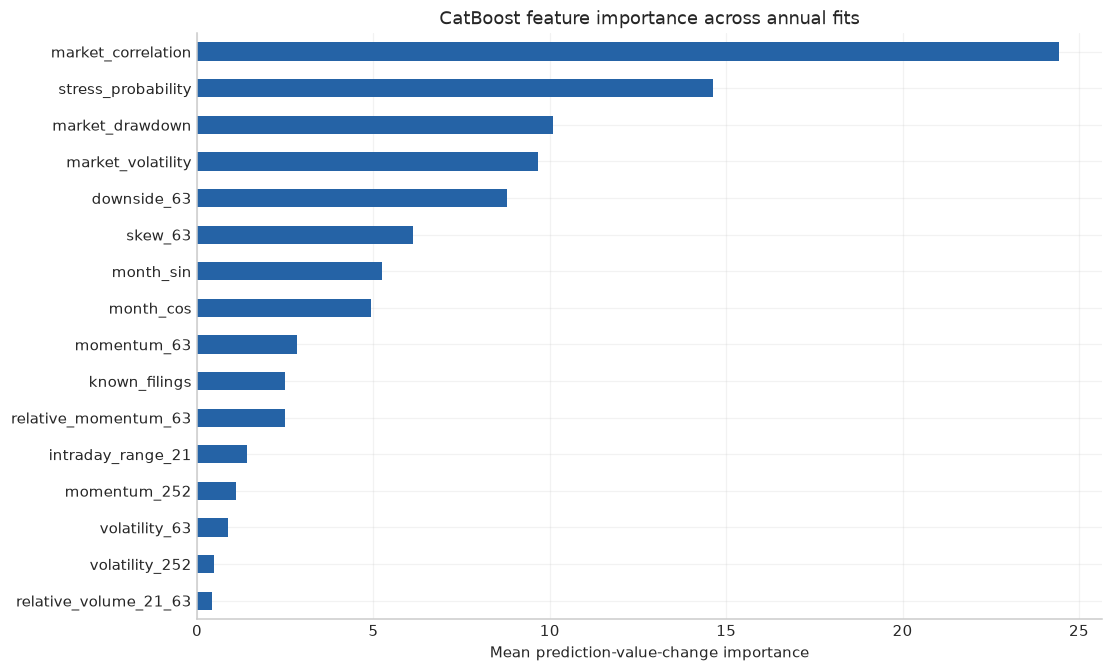

In [5]:
validation_predictions, validation_audit, validation_importance = validation_forecasts[ml_spec["depth"]]
display(validation_audit)
assert (pd.to_datetime(validation_audit.last_training_label_end) < pd.to_datetime(validation_audit.fit_date)).all()
display(prediction_diagnostics(validation_predictions))
importance_plot(validation_importance, "pipeline3_validation_importance")

### Held-out annual refits and common portfolio evaluation

,year,fit_date,training_rows,training_dates,last_training_formation,last_training_label_end,prediction_dates,depth,iterations,feature_set,features
0,2021,2021-01-04,6600,132,2020-12-01,2020-12-30,12,4,300,full,47
1,2022,2022-01-03,7200,144,2021-12-01,2021-12-30,12,4,300,full,47
2,2023,2023-01-03,7800,156,2022-12-01,2022-12-30,12,4,300,full,47
3,2024,2024-01-02,8350,167,2023-11-01,2023-11-30,12,4,300,full,47
4,2025,2025-01-02,9000,180,2024-12-02,2024-12-31,12,4,300,full,47
5,2026,2026-01-02,9600,192,2025-12-01,2025-12-30,2,4,300,full,47


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
pipeline2,8.04%,13.10%,0.656,0.932,17.88%,1.84%,2.88%,3.252,17.115
pipeline3,8.04%,13.08%,0.656,0.933,17.78%,1.83%,2.87%,3.179,17.628


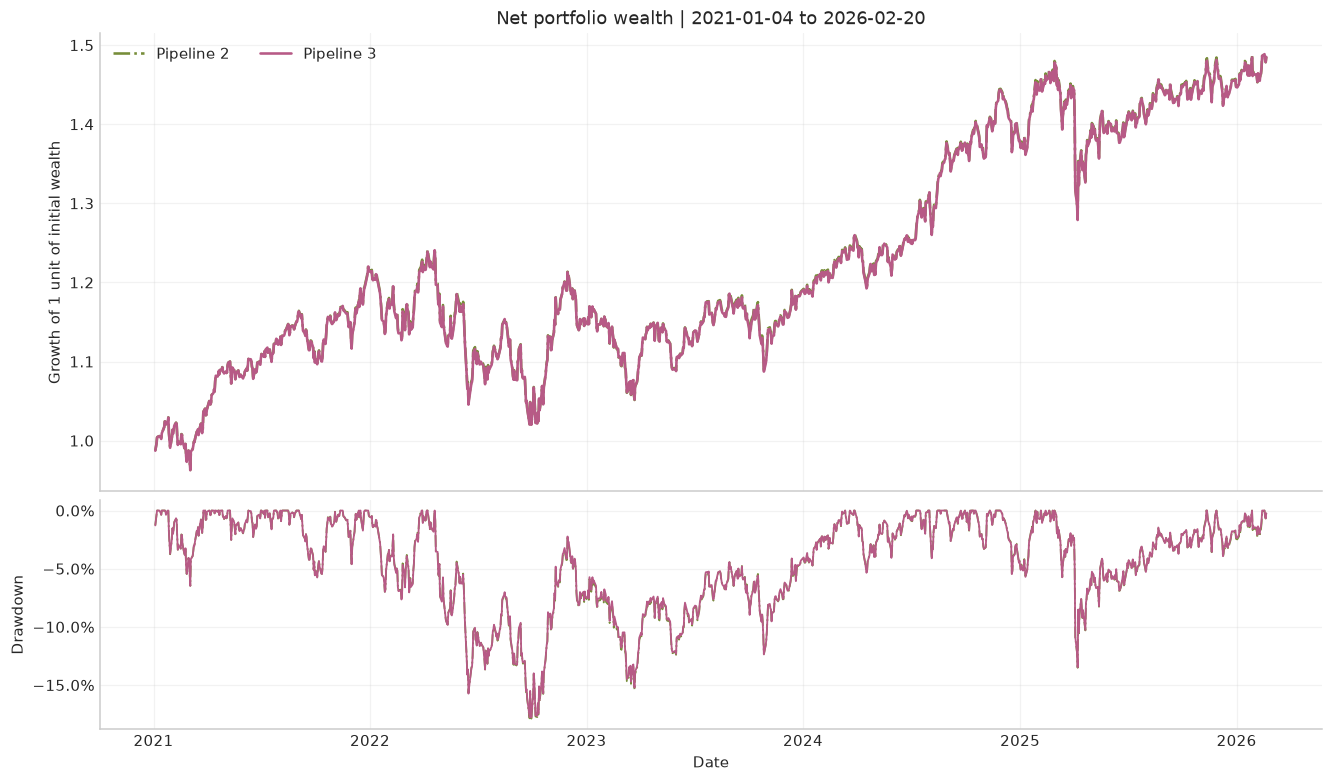

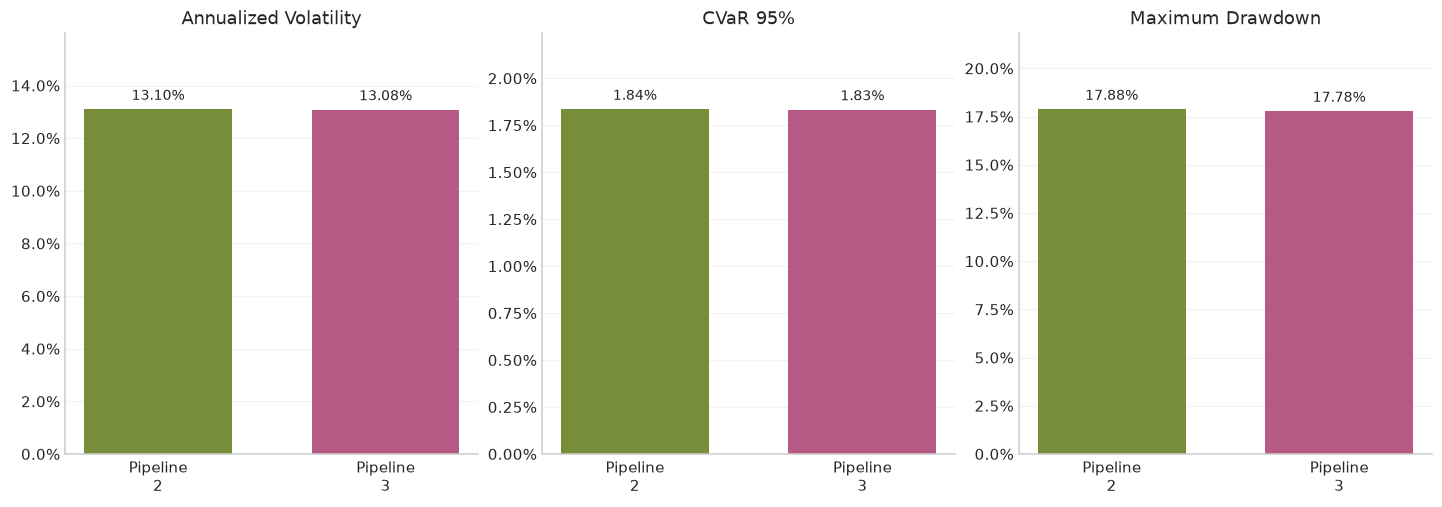

In [6]:
verify_frozen(c, spec)
test_predictions, test_audit, test_importance = forecast_risk(c["panel"], make_rebalance_dates(c["splits"]["test"], "M"), depth=ml_spec["depth"], feature_set="full", iterations=ml_spec["iterations"])
display(test_audit)
test_results = {"pipeline2": strategy(c, "test", "pipeline2", quality_strength),
                "pipeline3": strategy(c, "test", "pipeline3", quality_strength, test_predictions, ml_spec["ml_strength"])}
for name, result in test_results.items(): export_result(result, name, "test")
test_table = metric_table(test_results)
display(styled(test_table[METRIC_COLUMNS]))
performance_plot(test_results, "pipeline3_test_performance")
risk_plot(test_table, "pipeline3_test_risk")

### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

,Annualized Turnover,Total Transaction Costs,Average HHI,Average Effective Assets,Mean Target L1 Change,Solver Failures
pipeline2,3.252,1.66%,6.18%,17.115,0.253,0.000
pipeline3,3.179,1.63%,6.01%,17.628,0.247,0.000


,rows,months,log_risk_RMSE,mean_monthly_rank_IC,median_monthly_rank_IC
model,,,,,
Historical downside,3050,61,0.951689,0.521017,0.514526
CatBoost,3050,61,0.883598,0.580090,0.578872


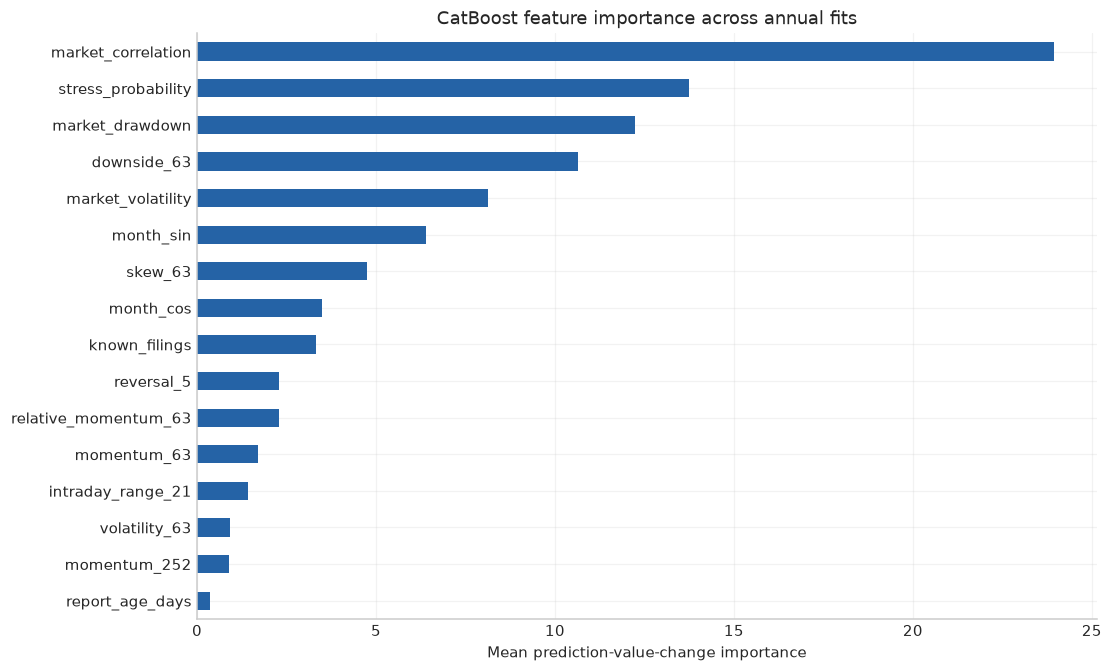

In [7]:
display(styled(test_table[["Annualized Turnover", "Total Transaction Costs", "Average HHI", "Average Effective Assets", "Mean Target L1 Change", "Solver Failures"]]))
display(prediction_diagnostics(test_predictions))
importance_plot(test_importance, "pipeline3_test_importance")

### Inspect forecast calibration

Points aggregate stocks into predicted-risk quintiles within each month and then average across months. This is descriptive calibration, not a trading strategy selected from test.

,predicted_downside_variance,future_downside_variance
risk_quintile,,
1,0.000056,0.000086
2,0.000078,0.000117
3,0.000101,0.000159
4,0.000135,0.000194
5,0.000254,0.000364


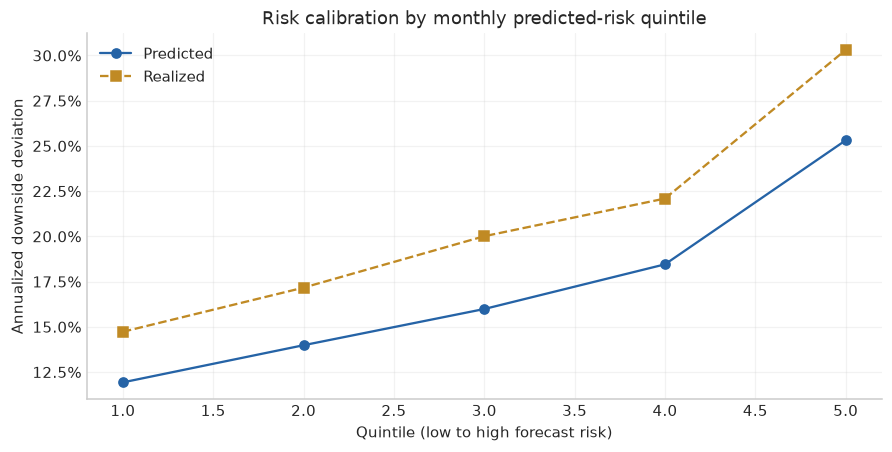

In [8]:
calibration = test_predictions.dropna(subset=["future_downside_variance"]).copy()
calibration["risk_quintile"] = calibration.groupby("date").predicted_downside_variance.transform(lambda x: pd.qcut(x.rank(method="first"), 5, labels=False) + 1)
calibration = calibration.groupby(["date", "risk_quintile"])[["predicted_downside_variance", "future_downside_variance"]].mean().groupby("risk_quintile").mean()
display(calibration)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(calibration.index, np.sqrt(calibration.predicted_downside_variance)*np.sqrt(252), marker="o", label="Predicted", color="#2563a6")
ax.plot(calibration.index, np.sqrt(calibration.future_downside_variance)*np.sqrt(252), marker="s", ls="--", label="Realized", color="#c08a24")
ax.set(title="Risk calibration by monthly predicted-risk quintile", xlabel="Quintile (low to high forecast risk)", ylabel="Annualized downside deviation")
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend();save(fig, "pipeline3_risk_calibration")

### Ablate the CatBoost feature groups

The explicit Pipeline 2 quality penalty remains in every row. These ablations isolate inputs to the **ML forecaster**, not the removal of all fundamental information from the allocation. Depth and penalty strength stay fixed at the full-model validation selection; ablations are not retuned on test.

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
price_regime,8.06%,13.09%,0.658,0.935,17.75%,1.83%,2.87%,3.178,17.632
plus_fundamentals,8.04%,13.09%,0.656,0.933,17.77%,1.83%,2.87%,3.177,17.627
full,8.04%,13.08%,0.656,0.933,17.78%,1.83%,2.87%,3.179,17.628


,difference,lower_95,upper_95
Annualized Volatility,-0.000161,-0.000274,-0.000037
CVaR 95%,-0.000024,-0.000152,0.000116
Maximum Drawdown,-0.001035,-0.003175,0.002638
Sharpe,0.000658,-0.011713,0.011604


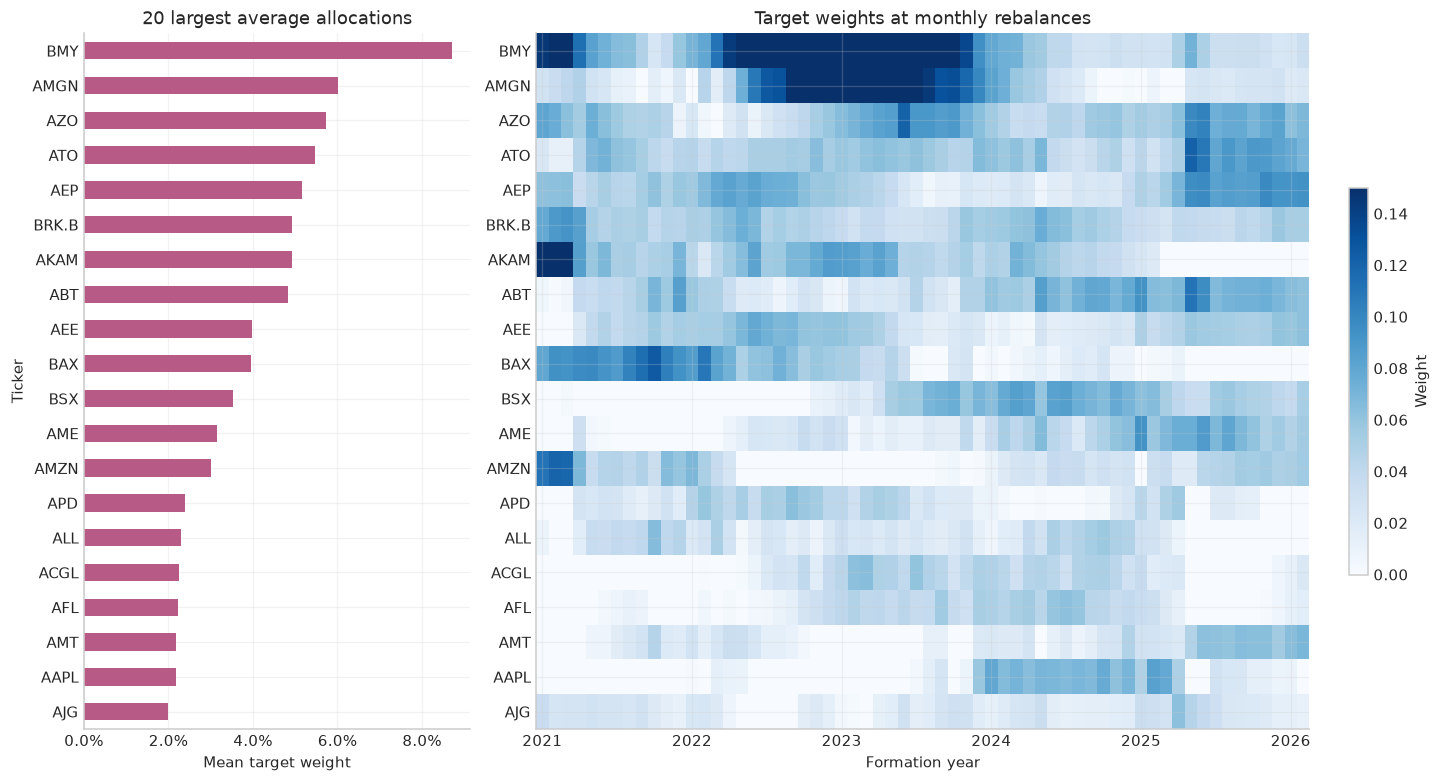

In [9]:
ablation_results = {name: load_result("pipeline3_" + name, "test") for name in ["price_regime", "plus_fundamentals"]}
ablation_results["full"] = test_results["pipeline3"]
display(styled(metric_table(ablation_results)[METRIC_COLUMNS]))
uncertainty = paired_bootstrap(test_results["pipeline2"].returns.net_return, test_results["pipeline3"].returns.net_return)
display(uncertainty)
allocation_plot(test_results["pipeline3"], "pipeline3_test_weights")

## Takeaways

In [10]:
p2, p3 = test_table.loc["pipeline2"], test_table.loc["pipeline3"]
pm = prediction_diagnostics(test_predictions)
display(Markdown(f"""Validation selects **depth {ml_spec['depth']}**, **{ml_spec['iterations']} trees** and **eta = {ml_spec['ml_strength']:g}**. On test, Pipeline 3 changes volatility by {(p3['Annualized Volatility']-p2['Annualized Volatility'])*100:+.3f} percentage points and daily CVaR95 by {(p3['CVaR 95%']-p2['CVaR 95%'])*100:+.3f} points relative to Pipeline 2. CatBoost's mean monthly rank IC is {pm.loc['CatBoost', 'mean_monthly_rank_IC']:.3f}, compared with {pm.loc['Historical downside', 'mean_monthly_rank_IC']:.3f} for historical downside risk. Better forecasts do not automatically imply a better constrained portfolio; use the incremental risk, return, turnover and uncertainty evidence together."""))

Validation selects **depth 4**, **300 trees** and **eta = 0.25**. On test, Pipeline 3 changes volatility by -0.016 percentage points and daily CVaR95 by -0.002 points relative to Pipeline 2. CatBoost's mean monthly rank IC is 0.580, compared with 0.521 for historical downside risk. Better forecasts do not automatically imply a better constrained portfolio; use the incremental risk, return, turnover and uncertainty evidence together.

## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): original selection and saved splits are preserved. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.